In [ ]:
from __future__ import annotations

import os

import torch
import librosa
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import Audio, display
from matplotlib.patches import Rectangle

from nd_aligner.config.ndaligner.training_module_config import NDAlignerTrainingModuleConfigs
from nd_aligner.config.utils.io import load_config
from nd_aligner.models.ndaligner import init_nd_aligner_training_module

# Load Models

In [7]:
# VCTK Only models

aligner_training_module_cfg_path = "../checkpoints/ndaligner/v2.3/VCTK/model_config.json"
aligner_training_module_ckpt_path = "../checkpoints/ndaligner/v2.3/VCTK/best_step_timit_bae_0.017094_step_143000_epoch_39.pth"

In [8]:
# VCTK + LibriSpeech

aligner_training_module_cfg_path = "../checkpoints/ndaligner/v2.3/VCTK+LibriSpeech/model_config.json"
aligner_training_module_ckpt_path = "../checkpoints/ndaligner/v2.3/VCTK+LibriSpeech/best_step_timit_bae_0.017166_step_267000_epoch_9.pth"

##### device settings

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
model_config = load_config(aligner_training_module_cfg_path, NDAlignerTrainingModuleConfigs,)
aligner_training_module = init_nd_aligner_training_module(config=model_config,  device=device)
aligner_training_module.load_checkpoint(
    ckpt_path=aligner_training_module_ckpt_path,
    device=device,
)
aligner = aligner_training_module.nd_aligner.eval()

Loading nested state_dict from key 'model' in ../checkpoints/ndaligner/v2.3/VCTK+LibriSpeech/best_step_timit_bae_0.017166_step_267000_epoch_9.pth
✅ All weights matched perfectly.
Checkpoint loading process finished.


## run one samples

In [10]:
wav_path = "./samples/SA1.WAV"
text = "She had your dark suit in greasy wash water all year."

In [11]:
assert aligner.input_maker is not None

with torch.inference_mode():
    batch = aligner.input_maker.make_with_audio(
        wav_paths=[wav_path],
        scripts=[text],
    )

    features = aligner.compute_alignments(
        x=batch.x,
        x_lengths=batch.x_lengths,
        y=batch.y,
        y_lengths=batch.y_lengths,
        cond=batch.cond, # type: ignore
        compute_soft_path=True,
        compute_hard_path=True,
    )

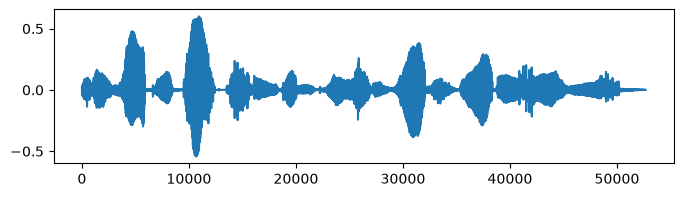

In [12]:
display(Audio(batch.wav_16k[0].detach().cpu().float().numpy(), rate=16000))

plt.figure(figsize=(8, 2))
plt.plot(batch.wav_16k[0].squeeze().detach().cpu().float().numpy())
plt.show()

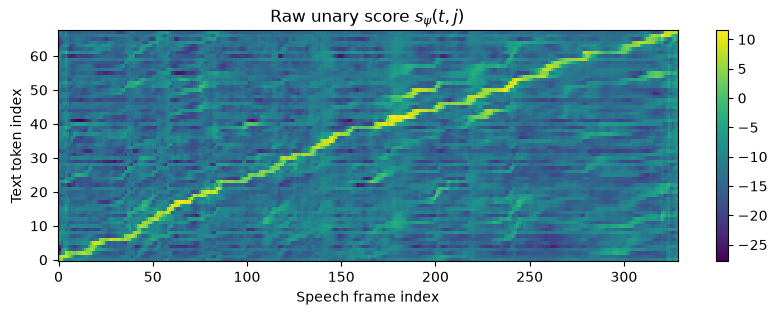

In [ ]:
raw_unary = features.raw_unary.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(raw_unary, origin="lower", aspect="auto", interpolation="nearest")
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Raw score $s_\psi(t,j)$")
plt.colorbar()
plt.show()

## Soft Alignments (A)

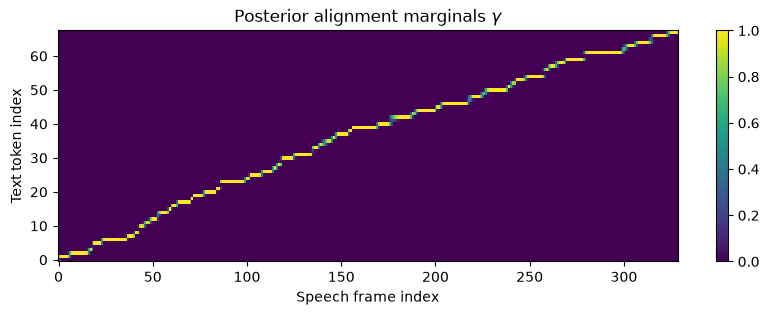

In [19]:
soft_attn = features.soft_attn.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(soft_attn, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Posterior alignment marginals A")
plt.show()

# Viterbi alignments (A(z*))

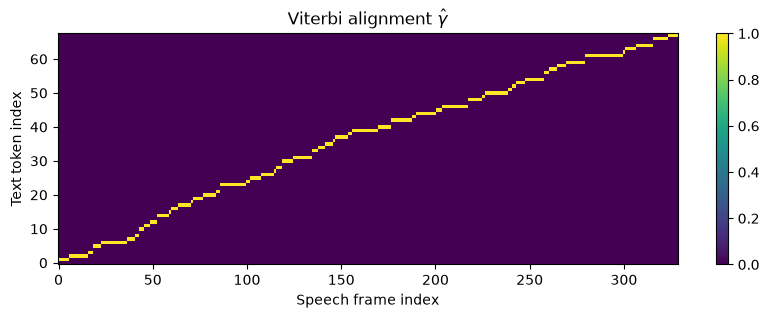

In [20]:
hard_attn = features.hard_attn.squeeze(0).T.cpu().detach().numpy()

plt.figure(figsize=(10, 3))
plt.imshow(hard_attn, origin="lower", aspect="auto", interpolation="nearest")
plt.colorbar()
plt.xlabel("Speech frame index")
plt.ylabel("Text token index")
plt.title(r"Viterbi alignment")
plt.show()

In [21]:
wav2_path = "./samples/SI2208.WAV"
text2 = "Yes, because you didn't run off to use that new toothbrush."

grids = aligner.inference_from_wavs(
    wav_paths=[wav_path, wav2_path],
    texts=[text, text2],
    compute_phone_grid=True,
    compute_word_grid=True,
    include_space_token_to_grid=True,
)

In [ ]:


def plot_alignment_with_waveform(
    wav_paths: str | Path | list[str | Path],
    grids,
    sample_idx: int = 0,
    *,
    sr: int | None = None,
    title: str | None = None,
    use_grid_time_range: bool = False,
    margin_sec: float = 0.03,
    figsize: tuple[float, float] = (16, 7),
    waveform_linewidth: float = 0.8,
    boundary_alpha: float = 0.85,
    boundary_linestyle: tuple[int, tuple[int, int]] = (0, (2, 3)),
    word_fontsize: int = 18,
    phone_fontsize: int = 16,
    title_fontsize: int = 22,
    xlabel_fontsize: int = 18,
    space_facecolor: str = "0.85",
    waveform_space_alpha: float = 0.75,
):
    if isinstance(wav_paths, (str, Path)):
        wav_path_list = [wav_paths]
    else:
        wav_path_list = list(wav_paths)

    wav_path = Path(wav_path_list[sample_idx])
    word_grid = grids.word_grid[sample_idx]
    phoneme_grid = grids.phoneme_grid[sample_idx]

    wav, loaded_sr = librosa.load(
        str(wav_path),
        sr=sr,
        mono=True,
    )

    sr_used = loaded_sr
    duration_sec = len(wav) / sr_used
    time_axis = np.arange(len(wav)) / sr_used

    if title is None:
        title = wav_path.stem

    if use_grid_time_range and (
        len(word_grid) > 0
        or len(phoneme_grid) > 0
    ):
        starts = []
        ends = []

        if len(word_grid) > 0:
            starts.append(word_grid[0][0])
            ends.append(word_grid[-1][1])

        if len(phoneme_grid) > 0:
            starts.append(phoneme_grid[0][0])
            ends.append(phoneme_grid[-1][1])

        x_min = max(
            0.0,
            min(starts) - margin_sec,
        )
        x_max = min(
            duration_sec,
            max(ends) + margin_sec,
        )
    else:
        x_min = 0.0
        x_max = duration_sec

    boundary_times: list[float] = []

    for start_sec, end_sec, _ in phoneme_grid:
        boundary_times.append(float(start_sec))
        boundary_times.append(float(end_sec))

    for start_sec, end_sec, _ in word_grid:
        boundary_times.append(float(start_sec))
        boundary_times.append(float(end_sec))

    boundary_times = sorted(set(boundary_times))

    space_regions = {
        (
            float(start_sec),
            float(end_sec),
        )
        for start_sec, end_sec, label in (
            list(word_grid) + list(phoneme_grid)
        )
        if str(label).strip() == ""
        and float(end_sec) > float(start_sec)
    }

    space_regions = sorted(space_regions)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={
            "height_ratios": [2.2, 1.4, 1.4],
            "hspace": 0.0,
        },
    )

    ax_wav, ax_word, ax_phone = axes

    # ------------------------------------------------------------
    # Waveform
    # ------------------------------------------------------------
    for start_sec, end_sec in space_regions:
        vis_start = max(start_sec, x_min)
        vis_end = min(end_sec, x_max)

        if vis_end <= vis_start:
            continue

        ax_wav.axvspan(
            vis_start,
            vis_end,
            facecolor=space_facecolor,
            alpha=waveform_space_alpha,
            linewidth=0.0,
            zorder=0,
        )

    ax_wav.plot(
        time_axis,
        wav,
        linewidth=waveform_linewidth,
        zorder=1,
    )
    ax_wav.set_xlim(x_min, x_max)
    ax_wav.set_yticks([])
    # ax_wav.set_title(
    #     title,
    #     fontsize=title_fontsize,
    #     pad=18,
    # )

    # ------------------------------------------------------------
    # Word tier
    # ------------------------------------------------------------
    ax_word.set_ylim(0, 1)
    ax_word.set_yticks([])

    for start_sec, end_sec, label in word_grid:
        start_sec = float(start_sec)
        end_sec = float(end_sec)

        if end_sec < x_min or start_sec > x_max:
            continue

        vis_start = max(start_sec, x_min)
        vis_end = min(end_sec, x_max)
        width = max(0.0, vis_end - vis_start)

        is_space = str(label).strip() == ""

        rect = Rectangle(
            (vis_start, 0),
            width,
            1,
            facecolor=(
                space_facecolor
                if is_space
                else "none"
            ),
            edgecolor="black",
            linewidth=1.0,
        )
        ax_word.add_patch(rect)

        center = (start_sec + end_sec) / 2.0

        if (
            x_min <= center <= x_max
            and not is_space
        ):
            ax_word.text(
                center,
                0.5,
                str(label),
                ha="center",
                va="center",
                fontsize=word_fontsize,
            )

    # ------------------------------------------------------------
    # Phoneme tier
    # ------------------------------------------------------------
    ax_phone.set_ylim(0, 1)
    ax_phone.set_yticks([])

    for start_sec, end_sec, label in phoneme_grid:
        start_sec = float(start_sec)
        end_sec = float(end_sec)

        if end_sec < x_min or start_sec > x_max:
            continue

        vis_start = max(start_sec, x_min)
        vis_end = min(end_sec, x_max)
        width = max(0.0, vis_end - vis_start)

        is_space = str(label).strip() == ""

        rect = Rectangle(
            (vis_start, 0),
            width,
            1,
            facecolor=(
                space_facecolor
                if is_space
                else "none"
            ),
            edgecolor="black",
            linewidth=1.0,
        )
        ax_phone.add_patch(rect)

        center = (start_sec + end_sec) / 2.0

        if (
            x_min <= center <= x_max
            and not is_space
        ):
            ax_phone.text(
                center,
                0.5,
                str(label),
                ha="center",
                va="center",
                fontsize=phone_fontsize,
            )

    # ------------------------------------------------------------
    # Alignment boundaries
    # ------------------------------------------------------------
    for t in boundary_times:
        if x_min <= t <= x_max:
            ax_wav.axvline(
                t,
                color="black",
                alpha=boundary_alpha,
                linestyle=boundary_linestyle,
                linewidth=1.0,
                zorder=2,
            )

            ax_word.axvline(
                t,
                color="black",
                alpha=boundary_alpha,
                linestyle=boundary_linestyle,
                linewidth=1.0,
            )

            ax_phone.axvline(
                t,
                color="black",
                alpha=boundary_alpha,
                linestyle=boundary_linestyle,
                linewidth=1.0,
            )

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

    ax_phone.tick_params(
        axis="x",
        labelsize=20,
    )

    ax_phone.set_xlabel(
        "Time (s)",
        fontsize=xlabel_fontsize,
    )

    fig.tight_layout()

    return fig, axes

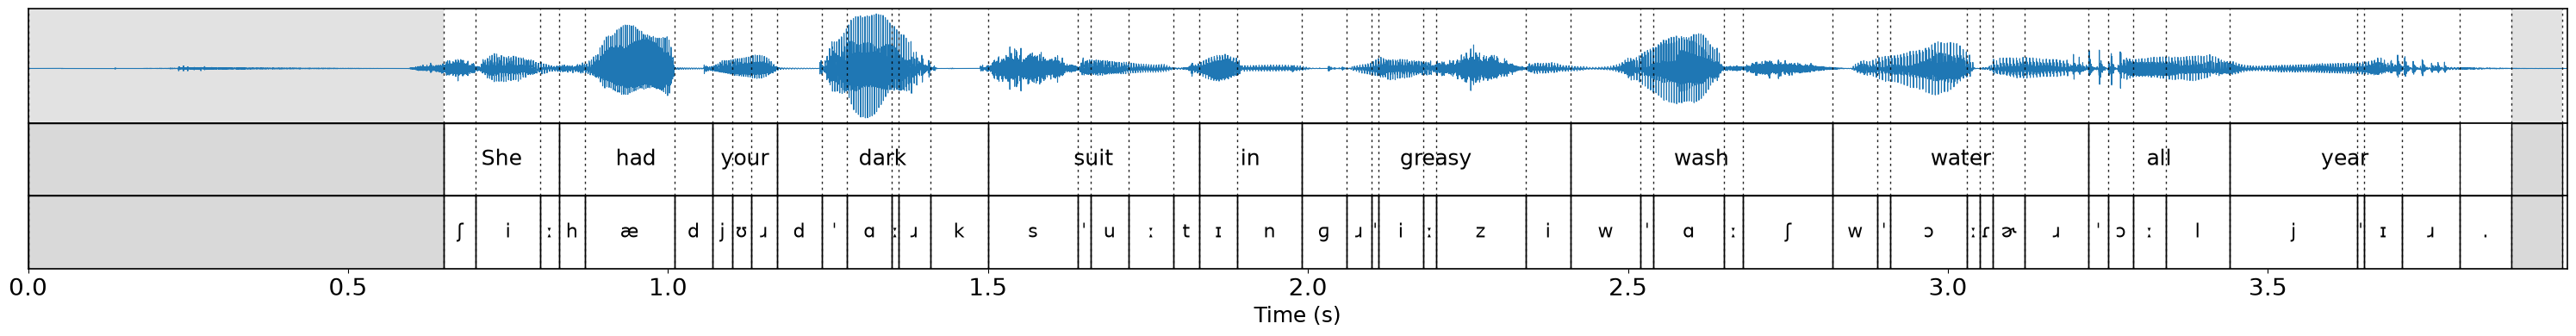

In [23]:
fig, axes = plot_alignment_with_waveform(
    wav_paths=[wav_path, wav2_path],
    grids=grids,
    sample_idx=0,
    use_grid_time_range=False,   # 전체 wav
    figsize=(30, 4)
)

# To Pratt TextGrids

In [24]:
textgrid_paths = aligner.align_to_textgrid(
    wav_paths=[wav_path, wav2_path],
    texts=[text, text2],
    output_dir="./textgrids",
    include_space_token=True,
)

for p in textgrid_paths:
    print(p)

print(open(textgrid_paths[0]).read()[:800])

textgrids/SA1.TextGrid
textgrids/SI2208.TextGrid
File type = "ooTextFile"
Object class = "TextGrid"

xmin = 0.0
xmax = 3.968
tiers? <exists>
size = 2
item []:
	item [1]:
		class = "IntervalTier"
		name = "words"
		xmin = 0.0
		xmax = 3.968
		intervals: size = 13
			intervals [1]:
				xmin = 0.0
				xmax = 0.65
				text = ""
			intervals [2]:
				xmin = 0.65
				xmax = 0.8300000000000001
				text = "She"
			intervals [3]:
				xmin = 0.8300000000000001
				xmax = 1.07
				text = "had"
			intervals [4]:
				xmin = 1.07
				xmax = 1.17
				text = "your"
			intervals [5]:
				xmin = 1.17
				xmax = 1.5
				text = "dark"
			intervals [6]:
				xmin = 1.5
				xmax = 1.83
				text = "suit"
			intervals [7]:
				xmin = 1.83
				xmax = 1.99
				text = "in"
			intervals [8]:
				xmin = 1.99
				xmax = 2.41
				text = "greasy"
			intervals [9]:
				x
